<a href="https://colab.research.google.com/github/Ian-123987/wsd-structured-product/blob/main/Structured_product_valuation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_2335/2860139753.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^FTSE", start="2021-02-24", end="2023-02-24")
[*********************100%***********************]  1 of 1 completed


0.14270782353763778
97.93088012131028 122.48274782536657
the expected value of a £1000 investment into this structured product in 6 years in 2023 pounds is 972.62


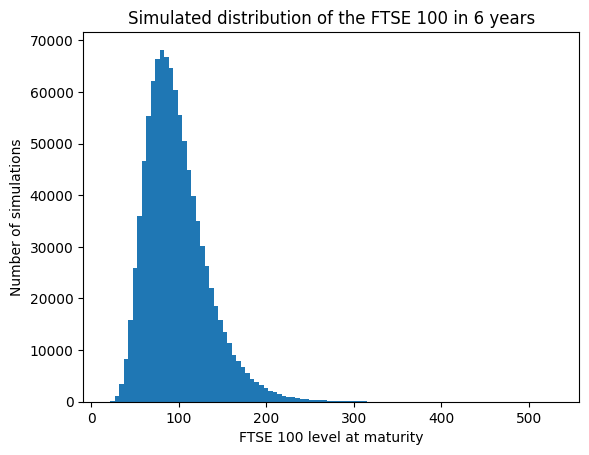

90th pct: £ 1664.1
50th pct: £ 1000.0
10th pct: £ 1000.0
1st pct: £ 1000.0
Bond part:      £ 816.44
Call part:      £ 156.07
Analytic total: £ 972.51
Monte Carlo:    £ 972.62
Skewness of simulated FTSE: 1.138
Mean: 97.93  Median: 92.07


In [2]:
# 6Y 100% capital protected Callable FTSE 100 participation note, https://www.nebafinancialsolutions.com/wp-content/uploads/2023/01/CS-6Y-100-Capital-Protected-Callable-FTSE-100-Participation-Note-GBP-XS2543838135.pdf
# From Credit Suisse, 150% participation rate
# This notebook will produce an expected value of the payoff from a simulation of the underlying and check against the Block-Scholes final value

!pip install -q yfinance
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import skew

data = yf.download("^FTSE", start="2021-02-24", end="2023-02-24")
prices = data["Close"]
log_returns = np.log(prices / prices.shift(1)).dropna()
sigma_draw = float((log_returns.std() * np.sqrt(252)).iloc[0])
print(sigma_draw)
# measures annualised volatility from a 2 year sample of the FTSE 100, standard deviation of daily log retunrs * sqrt(252) (to annualise over 252 trading days)

principal = 1000.0
FTSE_0 = 100.0
K = FTSE_0
Participation = 1.5
T = 6.0
r = 0.0338
# sourced from uk.investing.com 6 year gilt yield average over the month of February 2023, to represent the risk free value of the stock based on a no-arbitrage condition. Fixed to ensure stability
q = 0.0373
# yield rate from 2023 https://www.dividenddata.co.uk/ftse-index-yield.py$0
sigma = 0.143
# measured from 2 years of FTSE daily returns to Feb 2023, hardcoded for reproducability
N = 1000000

rng = np.random.default_rng(42)
Z = rng.standard_normal(N)

FTSE_T = FTSE_0 * np.exp((r - q - 0.5 * sigma ** 2)*T + sigma*np.sqrt(T)*Z)
# immediate move to maturity based on the fact that yearly variations are mutually independent
# 0.5 sigma^2 represents the Ito correction due to the use of GBM for the returns
# If there was some trigger in the path then we would need to model the whole process, however that isn't necessary here.

print(FTSE_T.mean(), FTSE_0*np.exp(r*T))
# the mean outcome should be centred around the drift, as it is

payoff = principal * (1 + Participation * np.maximum(FTSE_T/FTSE_0 - 1, 0))
expected_value = np.exp(-r*T) * payoff.mean()
print('the expected value of a £1000 investment into this structured product in 6 years in 2023 pounds is', round(expected_value,2))

plt.hist(FTSE_T, bins=100)
plt.xlabel("FTSE 100 level at maturity")
plt.ylabel("Number of simulations")
plt.title("Simulated distribution of the FTSE 100 in 6 years")
plt.show()

print("90th pct: £", round(np.percentile(payoff, 90), 2))
print("50th pct: £", round(np.percentile(payoff, 50), 2))
print("10th pct: £", round(np.percentile(payoff, 10), 2))
print("1st pct: £", round(np.percentile(payoff, 1), 2))

# unfavourable and stress should come out to exactly 1000 due to 100% capital protection
# ' Despite being capital protected against fluctuations in the Underlying Index all Capital may be at risk in the case of bankruptcy or default by the Issuer'
# Credit Suisse was in fact rescued, though the fact that it was rated A3 doesn't mean the risk of collapse is not worth considering

# checking the result using Black-Scholes, as a closed form solution exists
d1 = (np.log(FTSE_0/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)
call = FTSE_0*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

bond_value = principal * np.exp(-r*T)
embedded   = principal * Participation * (1/FTSE_0) * call
analytic_value = bond_value + embedded

print("Bond part:      £", round(bond_value, 2))
print("Call part:      £", round(embedded, 2))
print("Analytic total: £", round(analytic_value, 2))
print("Monte Carlo:    £", round(expected_value, 2))

# positive skew exists, as can be seen by the longer right tail in the Histogram, which is positive in the sense that the benefit from a strong FTSE is uncapped
print("Skewness of simulated FTSE:", round(skew(FTSE_T), 3))
print("Mean:", round(FTSE_T.mean(), 2), " Median:", round(np.median(FTSE_T), 2))